# Shadow Session Detection — Project R.E.M.

**Experimenteel notebook**

## Onderzoeksvraag (exploratief)

Deelnemers vulden een check-in formulier in bij elke *geregistreerde* luistersessie. Maar luisterden ze ook op andere momenten naar muziek — tijdens het pendelen, werken, ontspannen — zonder dat te registreren?

Dit notebook probeert **Candidate Listening Events (CLEs)** te detecteren: perioden waarbij de stressrespons sneller daalt dan op basis van de persoonlijke circadiane baseline verwacht zou worden, en waarbij geen geregistreerde sessie plaatsvond.

## Hoe werkt de detectie?

Muziek luisteren laat een biometrisch spoor achter: stress daalt sneller dan normaal (aangetoond in `recovery_analysis.ipynb`, gemiddeld voordeel +46.9 min). We zoeken ditzelfde patroon in de *niet-sessie* data:

1. **Markeer bekende sessies** — sluit elk geregistreerd sessievenster uit (sessie ±buffer)
2. **Scan de achtergronddata** — zoek perioden met verhoogde stress (≥ persoonlijk rustniveau) in rustige activiteitstoestand (Rust/Licht), overdag (7–22u)
3. **Fit exponentieel verval** — pas `stress(t) = asymptoot + (start - asymptoot) × e^(-t/τ)` toe
4. **Vergelijk tau** — is τ_werkelijk < τ_verwacht? Zo ja: het herstel was *sneller* dan normaal → CLE-kandidaat
5. **Scoor en rangschik** — advantage = τ_verwacht − τ_werkelijk

## Eerlijkheidswaarschuwing

> **Er is geen grondwaarheid.** Snellere-dan-baseline stressherstel kan ook door andere oorzaken komen: middagdutje, meditatie, rustpauze. We noemen detecties bewust *kandidaten*, niet bevestigde muziek-sessies. Dit is puur exploratief onderzoek.

## Deelnemers

| Deelnemer | Stressdata | Sessies | Status |
|---|---|---|---|
| bosbes | 96k rijen, jan–mrt 2026 | 10 | ✓ Volledig |
| kokosnoot | 161k rijen, jan–mei 2026 | 42 | ✓ Volledig |
| peer | 197k rijen, dec–mei 2026 | 31 | ⚠ Vereenvoudigde classifier |
| limoen | Huawei, 2.6% dekking | 11 | ✗ Uitgesloten |

In [31]:
from __future__ import annotations

import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd
from IPython.display import display
from scipy.optimize import curve_fit, OptimizeWarning

warnings.filterwarnings('ignore', category=OptimizeWarning)
warnings.filterwarnings('ignore', message='Glyph .* missing from font')

PROJECT_ROOT  = Path().resolve().parent.parent
DATA_ROOT     = PROJECT_ROOT / 'data'
WEARABLES_DIR = DATA_ROOT / 'wearables'
ANALYSIS_DIR  = DATA_ROOT / 'analysis'

# Donker thema (consistent met andere notebooks)
OI = {
    'sky_blue':       '#56B4E9',
    'orange':         '#E69F00',
    'bluish_green':   '#009E73',
    'reddish_purple': '#CC79A7',
    'vermilion':      '#D55E00',
    'blue':           '#0072B2',
    'yellow':         '#F0E442',
}
PARTICIPANT_COLORS = {
    'bosbes':    OI['sky_blue'],
    'kokosnoot': OI['orange'],
    'peer':      OI['reddish_purple'],
}
PLAYLIST_COLORS = {'Calm': OI['sky_blue'], 'Neutral': OI['yellow'], 'Energy': OI['vermilion']}

plt.rcParams.update({
    'figure.facecolor': '#0f1218', 'axes.facecolor': '#181e2a',
    'axes.edgecolor': '#232b3a', 'axes.labelcolor': '#c9d1d9',
    'axes.grid': True, 'grid.color': '#232b3a', 'grid.linewidth': 0.5,
    'text.color': '#c9d1d9', 'xtick.color': '#586475', 'ytick.color': '#586475',
    'legend.facecolor': '#181e2a', 'legend.edgecolor': '#232b3a',
    'font.family': 'monospace', 'font.size': 9, 'figure.dpi': 120,
})
print('Imports OK')

Imports OK


## Configuratie

Pas `WINDOW_MIN` aan om de breedte van het scanvenster te wijzigen.
`STEP_MIN` bepaalt hoe ver we opschuiven na elk geprobeerd venster (vermijdt overlappende CLEs).

In [32]:
# Deelnemers met volledige pipeline-uitvoer
FULL_PIPELINE   = ['bosbes', 'kokosnoot']
# Deelnemers met alleen biometrische data (vereenvoudigde classifier)
PARTIAL_PIPELINE = ['peer']
ALL_PARTICIPANTS = FULL_PIPELINE + PARTIAL_PIPELINE

# Scanparameters
WINDOW_MIN      = 60    # breedte van het herstelvenster (minuten)
STEP_MIN        = 15    # minimale tussenruimte tussen geprobeerde vensters
MIN_POINTS      = 10    # minimaal aantal niet-null stressmetingen in venster
R2_THRESHOLD    = 0.05  # minimale passkwaliteit
SCAN_STATES     = ['Rest', 'Light']  # alleen rusttoestanden
HOUR_MIN        = 7     # vroegste starttijd (uur)
HOUR_MAX        = 22    # laatste starttijd (uur)

# Sessiebuffers (minuten voor en na elke geregistreerde sessie uit te sluiten)
SESSION_BUFFER_PRE  = 30
SESSION_BUFFER_POST = 90

# Kwaliteitsfilter voor definitieve CLEs
CLE_MIN_ADVANTAGE = 0   # moet sneller zijn dan baseline

print('Configuratie geladen.')

Configuratie geladen.


## Hulpfuncties

De exponentiële vervalkurve en de lichtgewicht activiteitsclassificator (voor deelnemers zonder `classified_minutes.csv`).

In [33]:
def fit_exp_decay(
    t: np.ndarray,
    y: np.ndarray,
    asymptote: float,
) -> tuple[float, float] | None:
    """
    Fit y = asymptote + (y0 - asymptote) * exp(-t/tau).
    Geeft (tau, r²) of None als de fit mislukt.
    Identiek aan _fit_exp_decay() in scripts/baseline/baselines.py.
    """
    if len(y) < MIN_POINTS:
        return None
    y0_est  = float(y[0])
    tau_est = float(max(t[-1] / 3, 1.0))

    def model(t_, tau):
        return asymptote + (y0_est - asymptote) * np.exp(-t_ / tau)

    try:
        with warnings.catch_warnings():
            warnings.simplefilter('ignore', OptimizeWarning)
            popt, _ = curve_fit(model, t, y, p0=[tau_est], bounds=(0.1, 500), maxfev=2000)
        tau   = float(popt[0])
        y_hat = model(t, tau)
        ss_res = np.sum((y - y_hat) ** 2)
        ss_tot = np.sum((y - np.mean(y)) ** 2)
        r2    = float(1 - ss_res / ss_tot) if ss_tot > 0 else 0.0
        return tau, max(r2, 0.0)
    except (RuntimeError, ValueError):
        return None


def simple_activity_state(hr: float | None, hour: int) -> str:
    """
    Lichtgewicht activiteitsclassificator op basis van HR en tijdstip.
    Gebruikt als classified_minutes.csv niet beschikbaar is (bijv. peer).
    Minder nauwkeurig dan de volledige pipeline maar voldoende voor Rest/Light filtering.
    """
    if hr is None or np.isnan(hr):
        return 'Unknown'
    if hour < 7 or hour >= 22:
        return 'Sleep' if hr <= 95 else 'Rest'
    if hr >= 130:
        return 'Heavy'
    if hr >= 100:
        return 'Medium'
    if hr >= 78:
        return 'Light'
    return 'Rest'


def load_baselines(codename: str) -> dict:
    """
    Laad persoonlijke herstelcurve-parameters vanuit recovery_baselines.csv.
    Geeft {from_state: {'tau': float, 'asymptote': float}} voor stress-signaal.
    """
    path = ANALYSIS_DIR / codename / 'recovery_baselines.csv'
    if not path.exists():
        return {}
    df = pd.read_csv(path)
    stress = df[df['signal'] == 'stress']
    return {
        row['from_state']: {
            'tau':       float(row['tau_min']),
            'asymptote': float(row['asymptote']),
        }
        for _, row in stress.iterrows()
        if float(row['tau_min']) < 490  # tau=500 = mislukte meting, negeer
    }


def session_mask_for(codename: str) -> set:
    """
    Bereken de set van minuten die tot een geregistreerde sessie behoren.
    Breidt elke sessie uit met SESSION_BUFFER_PRE minuten voor en
    SESSION_BUFFER_POST minuten na de sessie.
    """
    path = WEARABLES_DIR / codename / 'processed' / 'session_biometrics.csv'
    if not path.exists():
        return set()
    sb = pd.read_csv(path)
    masked = set()
    for _, row in sb.iterrows():
        try:
            date_str  = str(row['date'])
            start_str = str(row['start_local']).strip()
            end_str   = str(row['end_local']).strip()
            start_dt  = pd.Timestamp(f"{date_str} {start_str}")
            end_dt    = pd.Timestamp(f"{date_str} {end_str}")
        except Exception:
            continue
        window_start = start_dt - pd.Timedelta(minutes=SESSION_BUFFER_PRE)
        window_end   = end_dt   + pd.Timedelta(minutes=SESSION_BUFFER_POST)
        ts = window_start
        while ts <= window_end:
            masked.add(ts.floor('min'))
            ts += pd.Timedelta(minutes=1)
    return masked


print('Hulpfuncties geladen.')

Hulpfuncties geladen.


## Data laden

Voor elke deelnemer laden we:
- `classified_minutes.csv` — stresswaarden + activiteitsstate per minuut
- `garmin_minute_stress.csv` — fallback voor peer (geen classified_minutes)
- `garmin_minute_hr.csv` — voor peer's vereenvoudigde classifier
- `recovery_baselines.csv` — persoonlijke τ per activiteitsstate
- `session_biometrics.csv` — tijdvensters van geregistreerde sessies

In [34]:
participant_data = {}

for codename in ALL_PARTICIPANTS:
    print(f'\n{codename} laden...')
    pdata = {'codename': codename}

    # ── 1. Stressdata laden ──────────────────────────────────────────────────
    classified_path = ANALYSIS_DIR / codename / 'classified_minutes.csv'
    stress_path     = WEARABLES_DIR / codename / 'processed' / 'garmin_minute_stress.csv'
    hr_path         = WEARABLES_DIR / codename / 'processed' / 'garmin_minute_hr.csv'

    if classified_path.exists():
        df = pd.read_csv(classified_path, parse_dates=['timestamp'])
        df = df.set_index('timestamp').sort_index()
        pdata['source'] = 'classified_minutes'
        print(f'  classified_minutes.csv: {len(df)} rijen  ({df.index.min().date()} → {df.index.max().date()})')
    elif stress_path.exists():
        # Fallback voor peer: combineer stress + HR
        df_s = pd.read_csv(stress_path, parse_dates=['timestamp']).set_index('timestamp').sort_index()
        if hr_path.exists():
            df_h = pd.read_csv(hr_path, parse_dates=['timestamp']).set_index('timestamp').sort_index()
            df   = df_s.join(df_h, how='outer')
        else:
            df = df_s
            df['heart_rate'] = np.nan
        # Genereer vereenvoudigde activiteitsstate
        df['activity_state'] = [
            simple_activity_state(row.get('heart_rate'), idx.hour)
            for idx, row in df.iterrows()
        ]
        pdata['source'] = 'garmin_raw (simplified classifier)'
        print(f'  garmin_minute_stress.csv: {len(df)} rijen (vereenvoudigde classifier)')
        print(f'  ⚠ Activiteitsstate zijn benaderend — geen stappen- of slaapdata beschikbaar')
    else:
        print(f'  ✗ Geen bruikbare stressdata gevonden — {codename} overgeslagen')
        continue

    pdata['df'] = df

    # ── 2. Baselines laden ───────────────────────────────────────────────────
    baselines = load_baselines(codename)
    if baselines:
        print(f'  Baselines: {list(baselines.keys())}')
    else:
        # Fallback voor peer: schat asymptoot uit stresspercentielen
        stress_vals = df['stress'].dropna()
        approx_asym = float(np.percentile(stress_vals, 10)) if len(stress_vals) > 100 else 25.0
        approx_tau  = 40.0  # conservatieve schatting
        for state in SCAN_STATES:
            baselines[state] = {'tau': approx_tau, 'asymptote': approx_asym}
        print(f'  ⚠ Geen recovery_baselines.csv — geschatte asymptoot={approx_asym:.1f}, τ={approx_tau}')
    pdata['baselines'] = baselines

    # ── 3. Sessiemask berekenen ──────────────────────────────────────────────
    mask = session_mask_for(codename)
    pdata['session_mask'] = mask
    n_sessions = len(pd.read_csv(
        WEARABLES_DIR / codename / 'processed' / 'session_biometrics.csv'
    )) if (WEARABLES_DIR / codename / 'processed' / 'session_biometrics.csv').exists() else 0
    print(f'  Sessiemasker: {len(mask)} minuten uitgesloten ({n_sessions} geregistreerde sessies)')

    participant_data[codename] = pdata

print(f'\nGeladen: {list(participant_data.keys())}')


bosbes laden...
  classified_minutes.csv: 146519 rijen  (2025-12-31 → 2026-03-10)
  Baselines: ['Heavy', 'Light', 'Medium', 'Rest', 'Sleep']
  Sessiemasker: 1534 minuten uitgesloten (10 geregistreerde sessies)

kokosnoot laden...
  classified_minutes.csv: 62705 rijen  (2026-01-15 → 2026-02-23)
  Baselines: ['Light', 'Medium', 'Rest', 'Sleep']
  Sessiemasker: 6280 minuten uitgesloten (42 geregistreerde sessies)

peer laden...
  garmin_minute_stress.csv: 240838 rijen (vereenvoudigde classifier)
  ⚠ Activiteitsstate zijn benaderend — geen stappen- of slaapdata beschikbaar
  ⚠ Geen recovery_baselines.csv — geschatte asymptoot=17.0, τ=40.0
  Sessiemasker: 4847 minuten uitgesloten (31 geregistreerde sessies)

Geladen: ['bosbes', 'kokosnoot', 'peer']


## Datadekking visualisatie

Beschikbare stressdata (groen) versus uitgesloten sessievensters (rood) per deelnemer. Dit geeft inzicht in hoeveel achtergronddata er overblijft voor de scan.

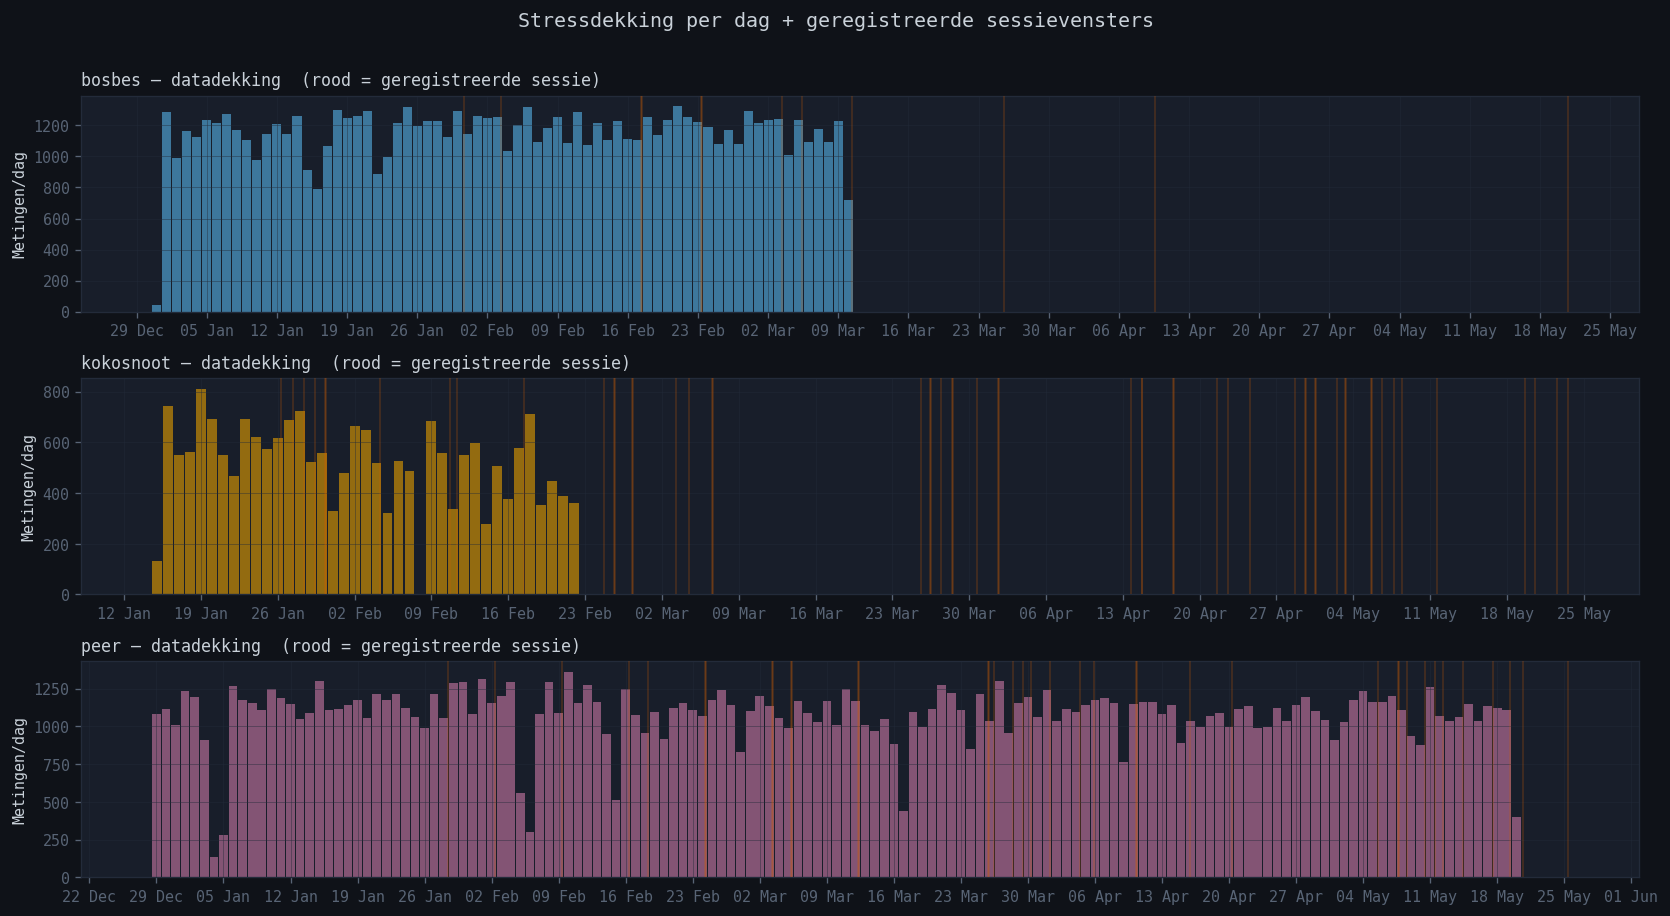

In [35]:
fig, axes = plt.subplots(len(participant_data), 1,
                         figsize=(14, 2.5 * len(participant_data)),
                         squeeze=False)

for ax_row, (codename, pdata) in zip(axes, participant_data.items()):
    ax = ax_row[0]
    df = pdata['df']

    # Stress-beschikbaarheid per dag
    df['date_only'] = df.index.date
    daily = df.groupby('date_only')['stress'].count().rename('n_stress')
    dates = [pd.Timestamp(d) for d in daily.index]

    ax.bar(dates, daily.values, width=0.9, color=PARTICIPANT_COLORS.get(codename, '#56B4E9'),
           alpha=0.6, label='Stressmetingen per dag')

    # Sessievensters markeren
    sb_path = WEARABLES_DIR / codename / 'processed' / 'session_biometrics.csv'
    if sb_path.exists():
        sb = pd.read_csv(sb_path)
        for _, row in sb.iterrows():
            try:
                start = pd.Timestamp(f"{row['date']} {str(row['start_local']).strip()}")
                end   = pd.Timestamp(f"{row['date']} {str(row['end_local']).strip()}")
                ax.axvspan(start, end, alpha=0.25, color=OI['vermilion'], zorder=5)
            except Exception:
                pass

    ax.set_title(f'{codename} — datadekking  (rood = geregistreerde sessie)', fontsize=10, loc='left')
    ax.set_ylabel('Metingen/dag')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0))

plt.suptitle('Stressdekking per dag + geregistreerde sessievensters', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

## CLE-detectie

**Algoritme (event-driven scanning):**

Voor elk niet-uitgesloten tijdstip waarbij:
- `stress ≥ asymptoot` (verhoogd — er is ruimte om te dalen)
- `activiteitsstate ∈ {Rust, Licht}`
- `uur ∈ [7, 22]`

Neem een venster van `WINDOW_MIN` minuten, fit een exponentieel verval, en bereken het voordeel.

Een CLE is betrouwbaar als `r² > 0.05` én `advantage > 0`.

In [36]:
def scan_cles(codename: str, pdata: dict) -> pd.DataFrame:
    """Scan op Candidate Listening Events voor één deelnemer."""
    df           = pdata['df']
    baselines    = pdata['baselines']
    session_mask = pdata['session_mask']

    # Alleen rijen met niet-null stress
    df_stress = df[df['stress'].notna()].copy()

    # Activiteitsstate nodig
    if 'activity_state' not in df_stress.columns:
        print(f'  [{codename}] Geen activiteitsstate beschikbaar — overgeslagen')
        return pd.DataFrame()

    cles          = []
    tried_windows = set()   # voorkomt overlappende vensters
    step          = pd.Timedelta(minutes=STEP_MIN)

    # Eligible startpunten
    eligible = df_stress[
        df_stress['activity_state'].isin(SCAN_STATES) &
        (df_stress.index.hour >= HOUR_MIN) &
        (df_stress.index.hour < HOUR_MAX)  &
        (~df_stress.index.floor('min').isin(session_mask))
    ]

    for ts, start_row in eligible.iterrows():
        ts_rounded = ts.floor(f'{STEP_MIN}min')
        if ts_rounded in tried_windows:
            continue
        tried_windows.add(ts_rounded)

        pre_state = start_row['activity_state']
        baseline  = baselines.get(pre_state)
        if baseline is None:
            # Probeer de andere scan-state als fallback
            for alt in SCAN_STATES:
                if alt != pre_state and alt in baselines:
                    baseline = baselines[alt]
                    break
        if baseline is None:
            continue

        asymptote    = baseline['asymptote']
        tau_expected = baseline['tau']
        start_stress = float(start_row['stress'])

        # Stress moet verhoogd zijn boven asymptoot
        if start_stress < asymptote:
            continue

        # Haal het venster op
        window_end  = ts + pd.Timedelta(minutes=WINDOW_MIN)
        window_data = df_stress.loc[ts:window_end]
        window_data = window_data[
            ~window_data.index.floor('min').isin(session_mask)
        ]
        window_stress = window_data['stress'].dropna()

        if len(window_stress) < MIN_POINTS:
            continue

        end_stress = float(window_stress.iloc[-1])

        # Stress moet netto dalen
        if end_stress >= start_stress:
            continue

        # Exponentieel verval fitten
        t = np.array(
            [(t_ - ts).total_seconds() / 60 for t_ in window_stress.index],
            dtype=float,
        )
        y = window_stress.values.astype(float)

        result = fit_exp_decay(t, y, asymptote)
        if result is None:
            continue
        tau_actual, r2 = result

        if r2 < R2_THRESHOLD:
            continue

        advantage = tau_expected - tau_actual

        # Body Battery delta (indien beschikbaar)
        bb_series = window_data['body_battery'].dropna() if 'body_battery' in window_data else pd.Series([], dtype=float)
        bb_delta  = float(bb_series.iloc[-1] - bb_series.iloc[0]) if len(bb_series) >= 2 else np.nan

        cles.append({
            'participant':        codename,
            'timestamp':          ts,
            'date':               ts.date(),
            'hour':               ts.hour,
            'day_of_week':        ts.day_name(),
            'pre_state':          pre_state,
            'pre_stress':         round(start_stress, 1),
            'end_stress':         round(end_stress, 1),
            'stress_decline':     round(start_stress - end_stress, 1),
            'asymptote':          round(asymptote, 1),
            'tau_actual':         round(tau_actual, 1),
            'tau_expected':       round(tau_expected, 1),
            'advantage':          round(advantage, 1),
            'r2':                 round(r2, 3),
            'body_battery_delta': round(bb_delta, 1) if not np.isnan(bb_delta) else np.nan,
            'n_points':           len(window_stress),
            'data_source':        pdata['source'],
        })

    result_df = pd.DataFrame(cles)
    if result_df.empty:
        return result_df
    return result_df[result_df['advantage'] >= CLE_MIN_ADVANTAGE].reset_index(drop=True)


# ── Scan alle deelnemers ──────────────────────────────────────────────────────
all_cles_list = []
for codename, pdata in participant_data.items():
    print(f'Scannen: {codename}...')
    cle_df = scan_cles(codename, pdata)
    print(f'  → {len(cle_df)} CLEs gevonden (advantage > 0, r²>{R2_THRESHOLD})')
    all_cles_list.append(cle_df)

all_cles = pd.concat(all_cles_list, ignore_index=True) if all_cles_list else pd.DataFrame()
print(f'\nTotaal: {len(all_cles)} CLE-kandidaten over {all_cles["participant"].nunique() if not all_cles.empty else 0} deelnemers')

Scannen: bosbes...
  → 293 CLEs gevonden (advantage > 0, r²>0.05)
Scannen: kokosnoot...
  → 91 CLEs gevonden (advantage > 0, r²>0.05)
Scannen: peer...
  → 338 CLEs gevonden (advantage > 0, r²>0.05)

Totaal: 722 CLE-kandidaten over 3 deelnemers


## Resultaten overzicht

CLE-samenvatting per deelnemer:



,n_cles,gem_advantage,gem_r2,gem_pre_stress,gem_decline
participant,,,,,
bosbes,293,27.36,0.23,42.97,18.01
kokosnoot,91,24.99,0.18,51.82,24.48
peer,338,17.02,0.40,57.06,31.72



Top 10 CLEs (hoogste advantage):


,participant,timestamp,pre_state,pre_stress,asymptote,tau_actual,tau_expected,advantage,r2
0,bosbes,2026-02-15 11:48:00,Light,63.0,25.9,0.1,61.8,61.7,0.24
1,kokosnoot,2026-01-24 12:33:00,Light,71.0,30.1,0.1,61.0,60.9,0.36
2,kokosnoot,2026-01-27 10:30:00,Light,57.0,30.1,0.1,61.0,60.9,0.13
3,kokosnoot,2026-02-01 13:34:00,Light,43.0,30.1,0.1,61.0,60.9,0.09
4,kokosnoot,2026-02-15 12:45:00,Light,54.0,30.1,0.1,61.0,60.9,0.08
5,kokosnoot,2026-01-27 10:29:00,Light,45.0,30.1,1.4,61.0,59.6,0.07
6,kokosnoot,2026-02-04 09:58:00,Light,59.0,30.1,1.8,61.0,59.2,0.13
7,bosbes,2026-02-26 19:16:00,Light,49.0,25.9,4.0,61.8,57.8,0.11
8,kokosnoot,2026-01-20 19:47:00,Light,66.0,30.1,4.1,61.0,56.9,0.25
9,bosbes,2026-02-03 10:15:00,Light,36.0,25.9,5.0,61.8,56.8,0.16


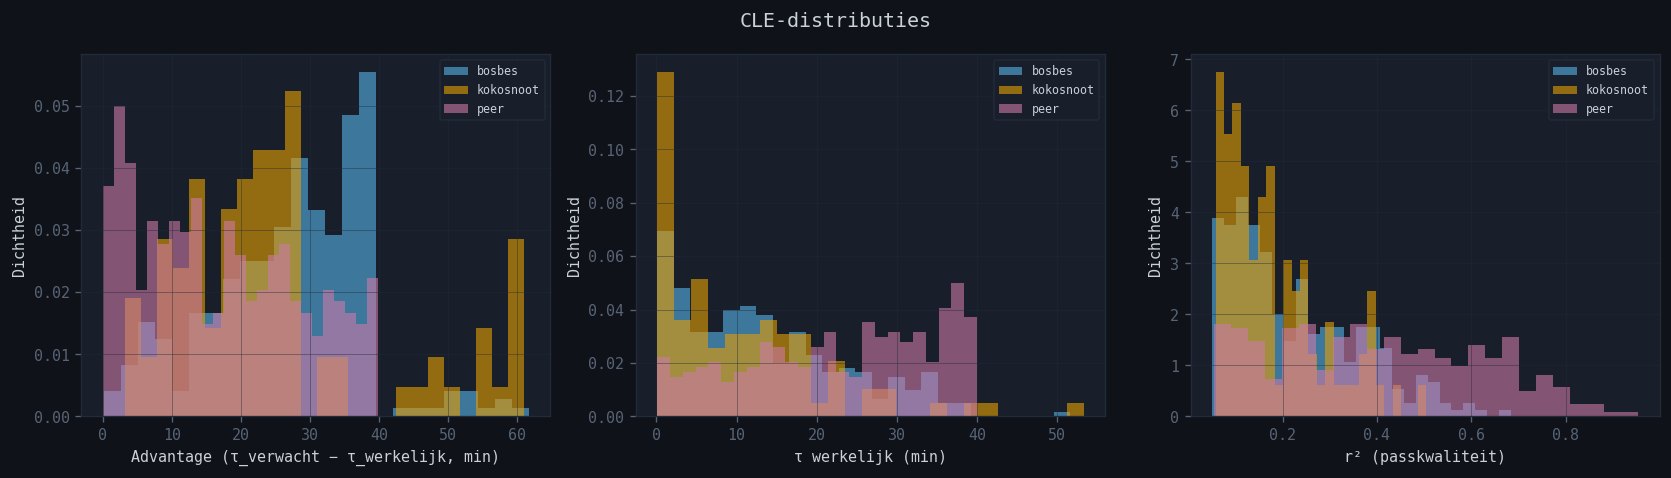

In [37]:
if all_cles.empty:
    print('Geen CLEs gevonden. Versoepel de drempelwaarden of controleer de data.')
else:
    print('CLE-samenvatting per deelnemer:\n')
    summary = (
        all_cles.groupby('participant')
        .agg(
            n_cles        = ('advantage', 'count'),
            gem_advantage = ('advantage', 'mean'),
            gem_r2        = ('r2', 'mean'),
            gem_pre_stress= ('pre_stress', 'mean'),
            gem_decline   = ('stress_decline', 'mean'),
        )
        .round(2)
    )
    display(summary)

    print('\nTop 10 CLEs (hoogste advantage):')
    cols_show = ['participant', 'timestamp', 'pre_state', 'pre_stress',
                 'asymptote', 'tau_actual', 'tau_expected', 'advantage', 'r2']
    display(
        all_cles.nlargest(10, 'advantage')[cols_show].reset_index(drop=True).round(2)
    )

    # Distributies
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))

    for ax, col, label in zip(
        axes,
        ['advantage', 'tau_actual', 'r2'],
        ['Advantage (τ_verwacht − τ_werkelijk, min)', 'τ werkelijk (min)', 'r² (passkwaliteit)'],
    ):
        for codename in all_cles['participant'].unique():
            vals = all_cles.loc[all_cles['participant'] == codename, col].dropna()
            ax.hist(vals, bins=25, alpha=0.6,
                    color=PARTICIPANT_COLORS.get(codename, '#888'),
                    label=codename, density=True)
        ax.set_xlabel(label)
        ax.set_ylabel('Dichtheid')
        ax.legend(fontsize=7)

    fig.suptitle('CLE-distributies', fontsize=12)
    plt.tight_layout()
    plt.show()

## Top-CLEs visualiseren

Voor elke deelnemer: de top-5 CLEs met hoogste advantage, geplot met stresstrajectorie + baseline-overlay.
Ter vergelijking wordt ook de gemiddelde stresstrajectorie van geregistreerde sessies getoond.

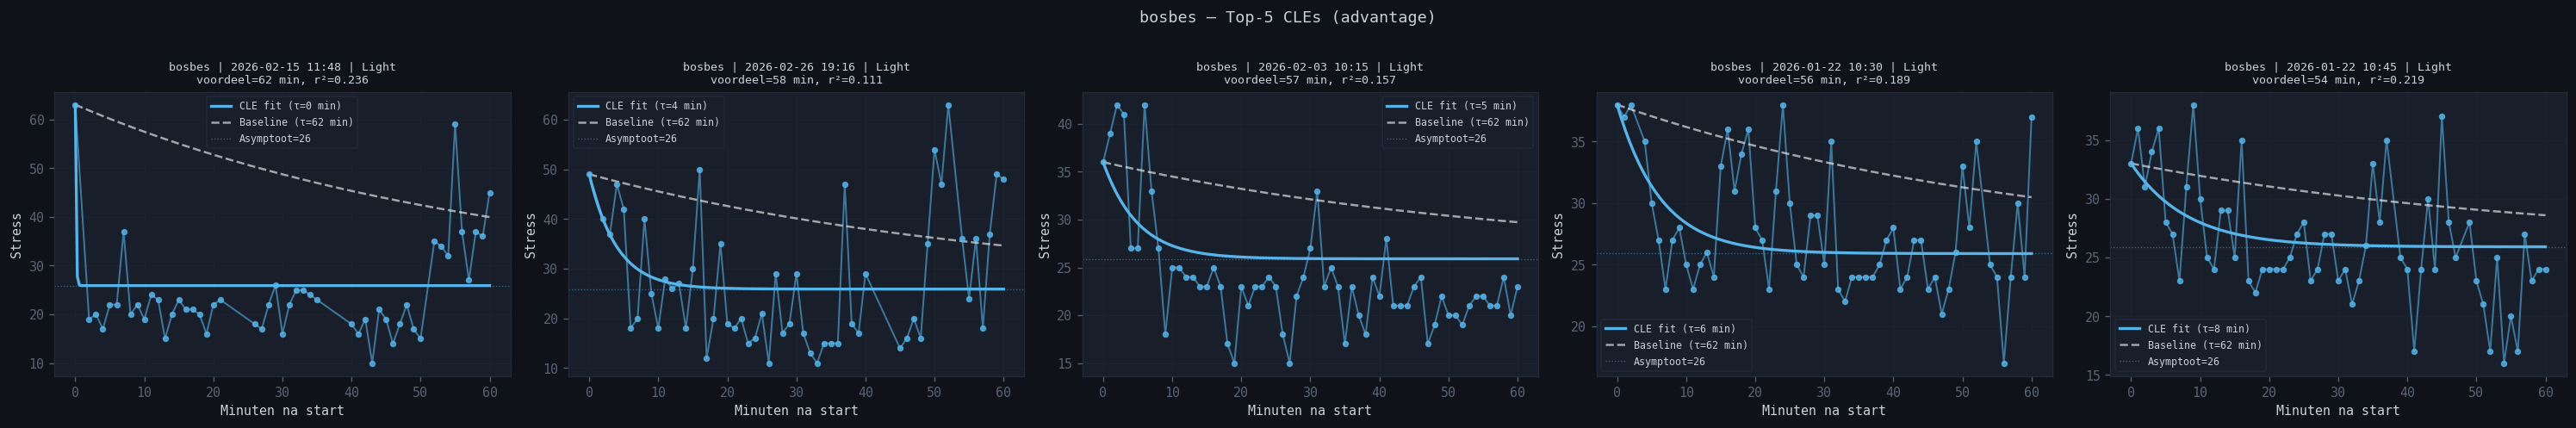

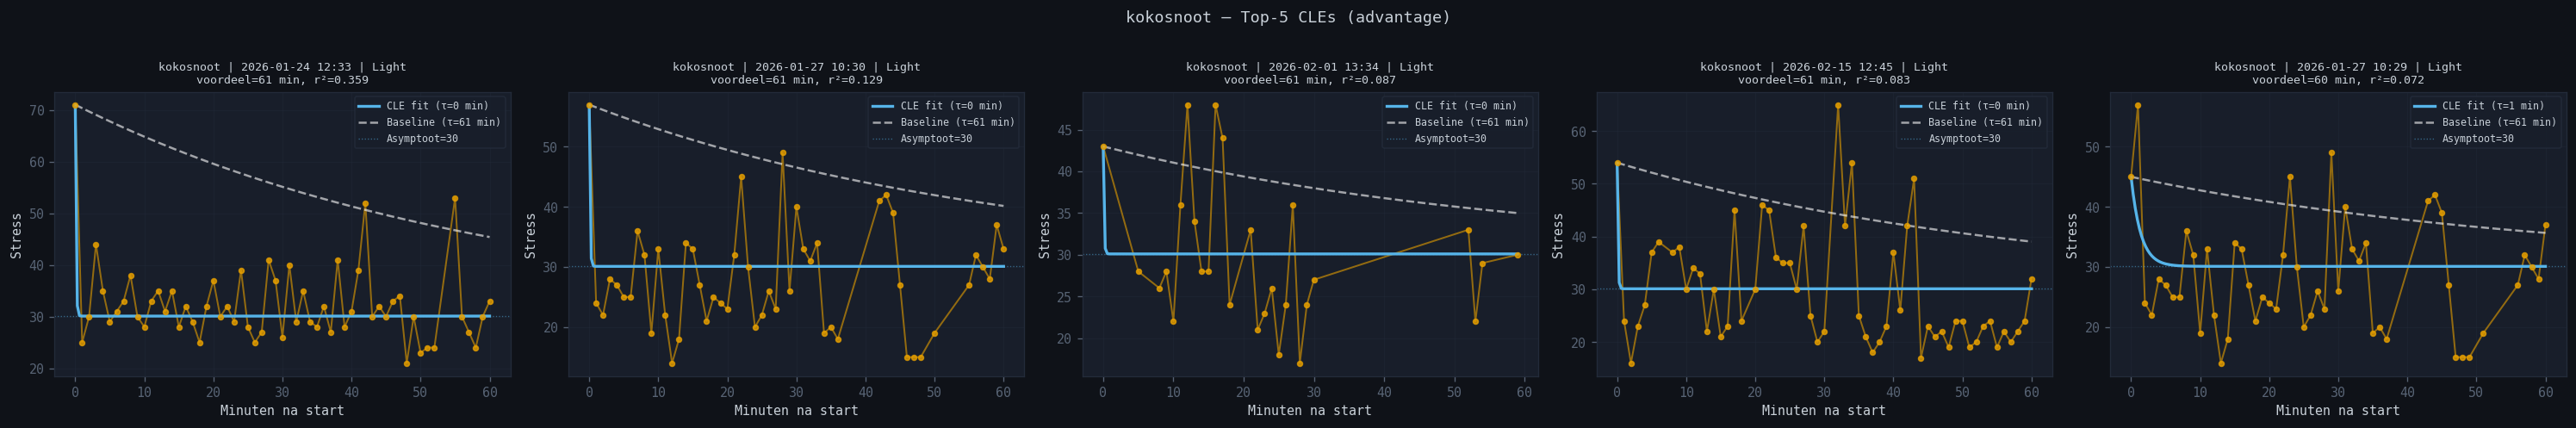

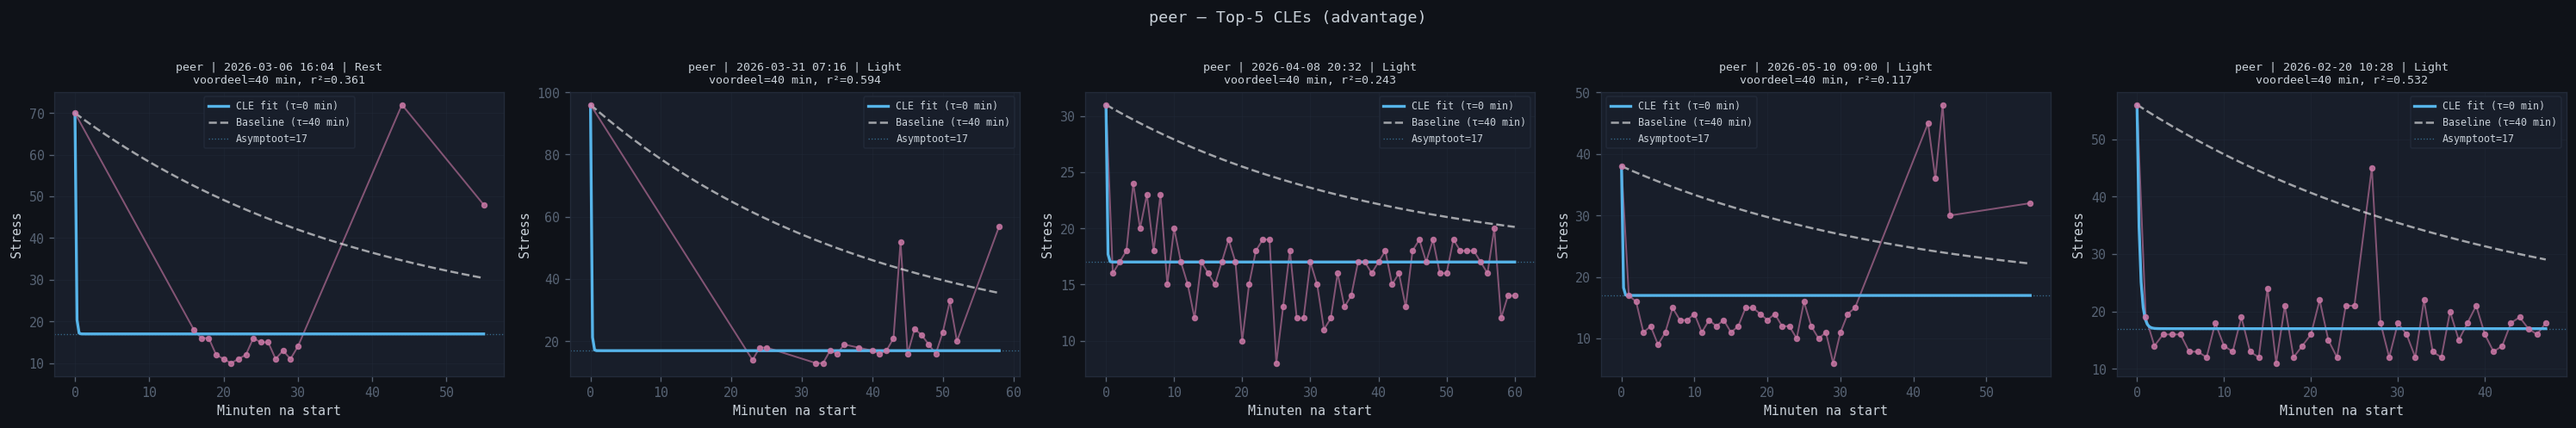

In [38]:
def plot_cle(
    ax,
    codename: str,
    cle_row: pd.Series,
    pdata: dict,
    n_minutes: int = WINDOW_MIN,
) -> None:
    """Plot één CLE: stresstrajectorie + exponentieel verval fit + baseline."""
    df        = pdata['df']
    baselines = pdata['baselines']
    ts        = cle_row['timestamp']
    pre_state = cle_row['pre_state']
    asymptote = cle_row['asymptote']
    tau_exp   = cle_row['tau_expected']
    tau_act   = cle_row['tau_actual']
    r2        = cle_row['r2']

    window_end  = ts + pd.Timedelta(minutes=n_minutes)
    window_data = df.loc[ts:window_end]
    stress_pts  = window_data['stress'].dropna()

    if stress_pts.empty:
        ax.text(0.5, 0.5, 'Geen data', ha='center', va='center', transform=ax.transAxes)
        return

    t_obs = np.array([(t_ - ts).total_seconds() / 60 for t_ in stress_pts.index])

    # Geobserveerde stresstrajectorie
    ax.scatter(t_obs, stress_pts.values, s=12, color=PARTICIPANT_COLORS.get(codename, '#888'),
               alpha=0.8, zorder=5)
    ax.plot(t_obs, stress_pts.values, color=PARTICIPANT_COLORS.get(codename, '#888'),
            linewidth=1.2, alpha=0.6)

    # Gefitte curve (CLE)
    t_fit  = np.linspace(0, t_obs[-1], 200)
    y_fit  = asymptote + (float(stress_pts.iloc[0]) - asymptote) * np.exp(-t_fit / tau_act)
    ax.plot(t_fit, y_fit, color=OI['sky_blue'], linewidth=2, linestyle='-',
            label=f'CLE fit (τ={tau_act:.0f} min)')

    # Baseline (verwachte herstelcurve)
    y_base = asymptote + (float(stress_pts.iloc[0]) - asymptote) * np.exp(-t_fit / tau_exp)
    ax.plot(t_fit, y_base, color='white', linewidth=1.5, linestyle='--', alpha=0.6,
            label=f'Baseline (τ={tau_exp:.0f} min)')

    ax.axhline(asymptote, color=OI['sky_blue'], linewidth=0.8, linestyle=':', alpha=0.5,
               label=f'Asymptoot={asymptote:.0f}')

    ax.set_xlabel('Minuten na start')
    ax.set_ylabel('Stress')
    ax.set_title(
        f'{codename} | {ts.strftime("%Y-%m-%d %H:%M")} | {pre_state}\n'
        f'voordeel={cle_row["advantage"]:.0f} min, r²={r2:.3f}',
        fontsize=8,
    )
    ax.legend(fontsize=7)


if not all_cles.empty:
    TOP_N = 5
    for codename in participant_data:
        p_cles = all_cles[all_cles['participant'] == codename].nlargest(TOP_N, 'advantage')
        if p_cles.empty:
            print(f'{codename}: geen CLEs om te visualiseren')
            continue

        n_show = len(p_cles)
        fig, axes = plt.subplots(1, n_show, figsize=(5 * n_show, 4), squeeze=False)
        for ax, (_, row) in zip(axes[0], p_cles.iterrows()):
            plot_cle(ax, codename, row, participant_data[codename])

        fig.suptitle(f'{codename} — Top-{n_show} CLEs (advantage)', fontsize=11, y=1.02)
        plt.tight_layout()
        plt.show()

## CLEs vs. geregistreerde sessies

Vergelijken we de advantage-distributie van CLEs met die van geregistreerde sessies?
Als de distributies overlappen, suggereren CLEs een vergelijkbaar biometrisch patroon.
Als CLEs gemiddeld een *lager* voordeel hebben, zijn ze consistente met zwakkere of kortere muziek-effecten.

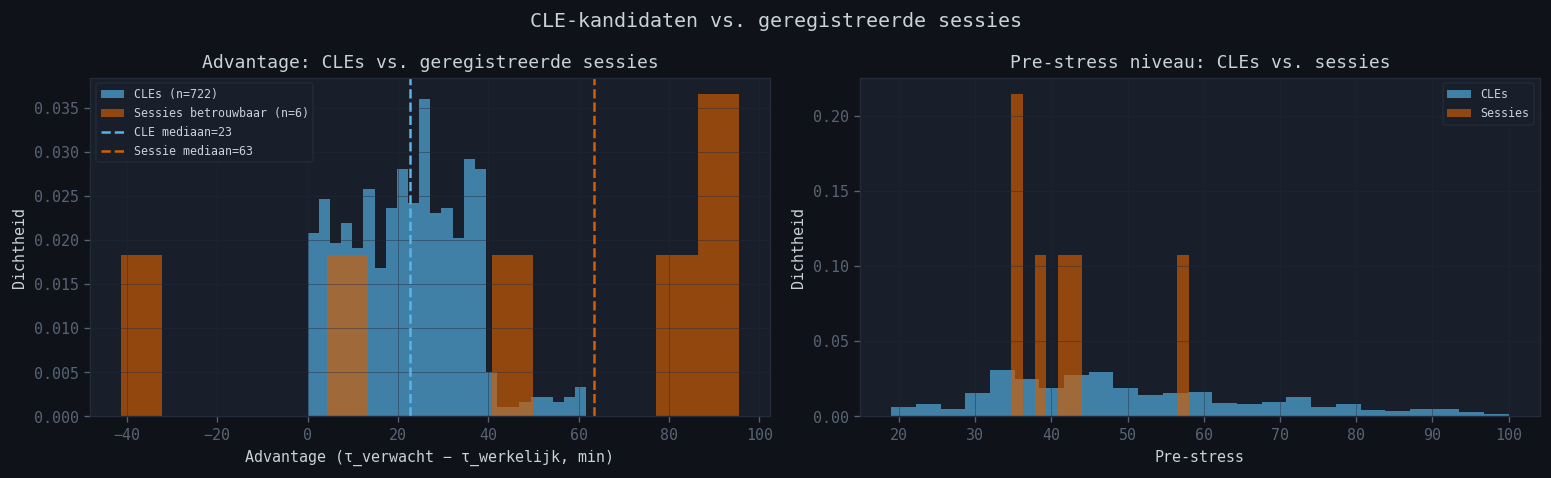


Interpretatie:
  CLE mediaan advantage:    22.6 min
  Sessie mediaan advantage: 63.4 min
  Verschil:                 -40.8 min
  → CLEs tonen een zwakker hersteleffect dan geregistreerde sessies.
    Dit kan wijzen op: kortere luisterduur, ander muziektype, of valse detecties.


In [39]:
# Laad geregistreerde sessie-advantages vanuit recovery_features.csv
rec_features_path = ANALYSIS_DIR / 'recovery_features.csv'

if rec_features_path.exists() and not all_cles.empty:
    rec = pd.read_csv(rec_features_path)
    rec_reliable = rec[rec['reliable'] == True].copy()

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    # ── Advantage distributie ─────────────────────────────────────────────────
    ax = axes[0]
    ax.hist(all_cles['advantage'].dropna(), bins=25, alpha=0.65,
            color=OI['sky_blue'], label=f'CLEs (n={len(all_cles)})', density=True)
    if not rec_reliable.empty:
        ax.hist(rec_reliable['advantage'].dropna(), bins=15, alpha=0.65,
                color=OI['vermilion'], label=f'Sessies betrouwbaar (n={len(rec_reliable)})', density=True)

    ax.axvline(all_cles['advantage'].median(), color=OI['sky_blue'],
               linewidth=1.5, linestyle='--', label=f'CLE mediaan={all_cles["advantage"].median():.0f}')
    if not rec_reliable.empty:
        ax.axvline(rec_reliable['advantage'].median(), color=OI['vermilion'],
                   linewidth=1.5, linestyle='--',
                   label=f'Sessie mediaan={rec_reliable["advantage"].median():.0f}')
    ax.set_xlabel('Advantage (τ_verwacht − τ_werkelijk, min)')
    ax.set_ylabel('Dichtheid')
    ax.set_title('Advantage: CLEs vs. geregistreerde sessies')
    ax.legend(fontsize=7)

    # ── Pre-stress vergelijking ───────────────────────────────────────────────
    ax = axes[1]
    ax.hist(all_cles['pre_stress'].dropna(), bins=25, alpha=0.65,
            color=OI['sky_blue'], label='CLEs', density=True)
    if 'pre_stress_mean' in rec.columns and not rec_reliable.empty:
        ax.hist(rec_reliable['pre_stress_mean'].dropna(), bins=15, alpha=0.65,
                color=OI['vermilion'], label='Sessies', density=True)
    ax.set_xlabel('Pre-stress')
    ax.set_ylabel('Dichtheid')
    ax.set_title('Pre-stress niveau: CLEs vs. sessies')
    ax.legend(fontsize=7)

    fig.suptitle('CLE-kandidaten vs. geregistreerde sessies', fontsize=12)
    plt.tight_layout()
    plt.show()

    print('\nInterpretatie:')
    cle_med = all_cles['advantage'].median()
    if not rec_reliable.empty:
        sess_med = rec_reliable['advantage'].median()
        diff = cle_med - sess_med
        print(f'  CLE mediaan advantage:    {cle_med:.1f} min')
        print(f'  Sessie mediaan advantage: {sess_med:.1f} min')
        print(f'  Verschil:                 {diff:+.1f} min')
        if diff < -10:
            print('  → CLEs tonen een zwakker hersteleffect dan geregistreerde sessies.')
            print('    Dit kan wijzen op: kortere luisterduur, ander muziektype, of valse detecties.')
        elif diff > 10:
            print('  → CLEs tonen een sterker hersteleffect dan geregistreerde sessies.')
            print('    Mogelijke verklaring: spontaan muziek luisteren bij hogere stresspiek.')
        else:
            print('  → CLEs en sessies tonen vergelijkbare advantage-distributies.')
else:
    print('recovery_features.csv niet gevonden of geen CLEs — vergelijking overgeslagen.')

## Temporeel patroon — Wanneer doen CLEs zich voor?

Heatmap van CLE-dichtheid per uur × dag van de week. Vergelijking met timing van geregistreerde sessies.

**Hypothese:** Als mensen spontaan muziek luisteren op vaste momenten (ochtend, middagpauze, avond), zou dat zichtbaar moeten worden als clusters in de heatmap.

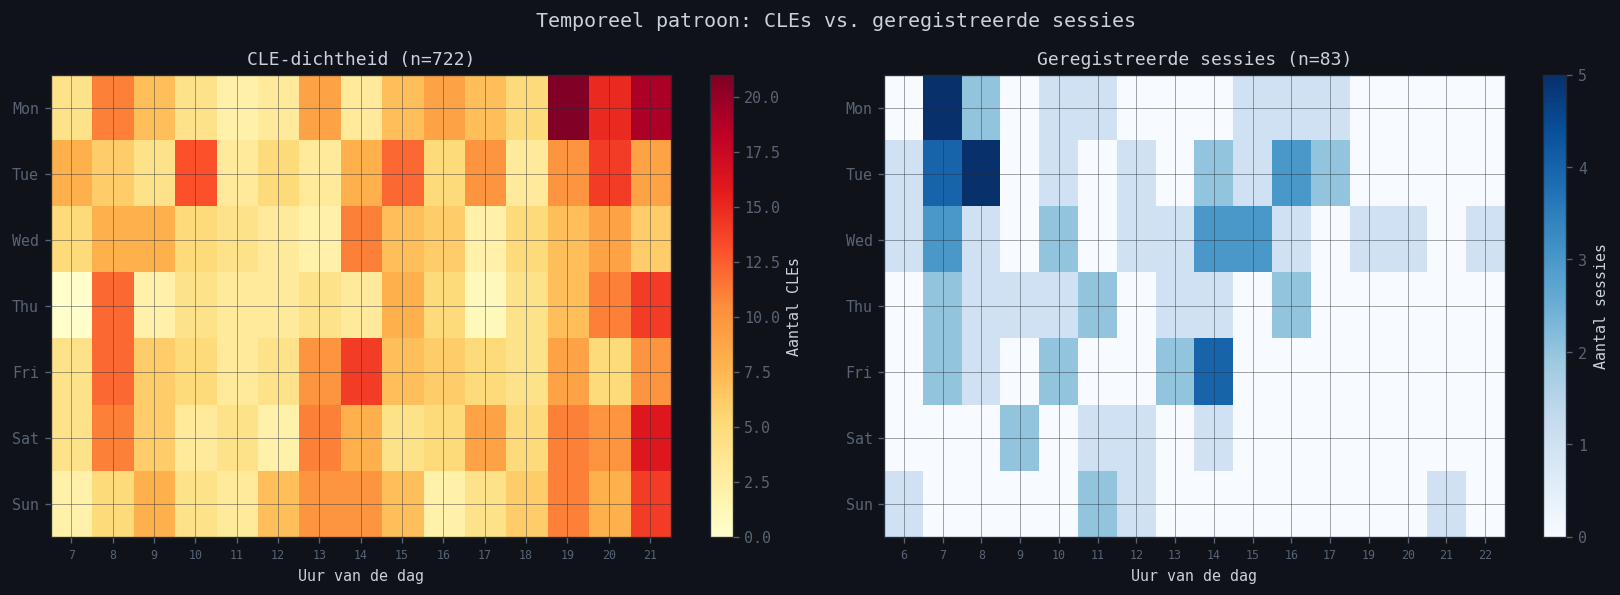

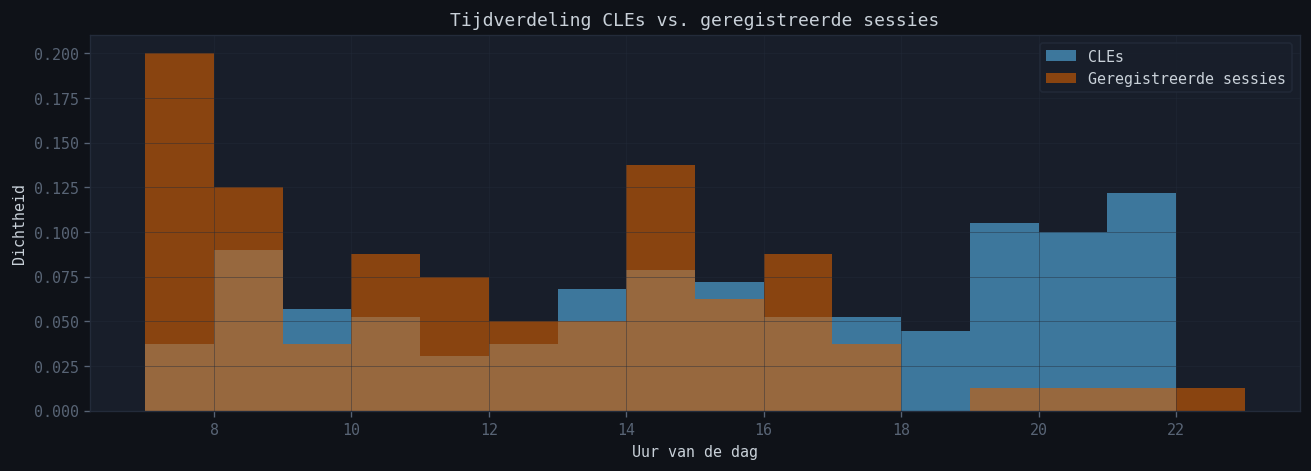

In [40]:
if not all_cles.empty:
    DAY_ORDER = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # ── CLE heatmap ──────────────────────────────────────────────────────────
    ax = axes[0]
    pivot_cle = (
        all_cles.groupby(['day_of_week', 'hour'])
        .size()
        .unstack(fill_value=0)
        .reindex(DAY_ORDER, fill_value=0)
    )
    im = ax.imshow(pivot_cle.values, aspect='auto', cmap='YlOrRd',
                   interpolation='nearest')
    ax.set_yticks(range(len(DAY_ORDER)))
    ax.set_yticklabels([d[:3] for d in DAY_ORDER])
    ax.set_xticks(range(len(pivot_cle.columns)))
    ax.set_xticklabels([str(h) for h in pivot_cle.columns], fontsize=7)
    ax.set_xlabel('Uur van de dag')
    ax.set_title(f'CLE-dichtheid (n={len(all_cles)})')
    plt.colorbar(im, ax=ax, label='Aantal CLEs')

    # ── Geregistreerde sessies heatmap ────────────────────────────────────────
    ax = axes[1]
    sess_rows = []
    for codename in participant_data:
        sb_path = WEARABLES_DIR / codename / 'processed' / 'session_biometrics.csv'
        if sb_path.exists():
            sb = pd.read_csv(sb_path)
            for _, row in sb.iterrows():
                try:
                    start = pd.Timestamp(f"{row['date']} {str(row['start_local']).strip()}")
                    sess_rows.append({'day_of_week': start.day_name(), 'hour': start.hour})
                except Exception:
                    pass
    sess_df = pd.DataFrame(sess_rows)

    if not sess_df.empty:
        pivot_sess = (
            sess_df.groupby(['day_of_week', 'hour'])
            .size()
            .unstack(fill_value=0)
            .reindex(DAY_ORDER, fill_value=0)
        )
        im2 = ax.imshow(pivot_sess.values, aspect='auto', cmap='Blues',
                        interpolation='nearest')
        ax.set_yticks(range(len(DAY_ORDER)))
        ax.set_yticklabels([d[:3] for d in DAY_ORDER])
        ax.set_xticks(range(len(pivot_sess.columns)))
        ax.set_xticklabels([str(h) for h in pivot_sess.columns], fontsize=7)
        ax.set_xlabel('Uur van de dag')
        ax.set_title(f'Geregistreerde sessies (n={len(sess_df)})')
        plt.colorbar(im2, ax=ax, label='Aantal sessies')

    fig.suptitle('Temporeel patroon: CLEs vs. geregistreerde sessies', fontsize=12)
    plt.tight_layout()
    plt.show()

    # ── Uurhistogram overlay ──────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(11, 4))
    ax.hist(all_cles['hour'], bins=range(HOUR_MIN, HOUR_MAX + 2),
            alpha=0.6, color=OI['sky_blue'], label='CLEs', density=True)
    if not sess_df.empty:
        ax.hist(sess_df['hour'], bins=range(HOUR_MIN, HOUR_MAX + 2),
                alpha=0.6, color=OI['vermilion'], label='Geregistreerde sessies', density=True)
    ax.set_xlabel('Uur van de dag')
    ax.set_ylabel('Dichtheid')
    ax.set_title('Tijdverdeling CLEs vs. geregistreerde sessies')
    ax.legend()
    plt.tight_layout()
    plt.show()

## Dosage-schatting

Hoeveel CLEs per week vinden we versus geregistreerde sessies per week?
Dit is een ruwe schatting van de verhouding geregistreerd/ongeregistreerd muziekgebruik.

In [41]:
if not all_cles.empty:
    print('Dosage-schatting (CLEs per week vs. geregistreerde sessies per week):\n')
    rows = []
    for codename, pdata in participant_data.items():
        df = pdata['df']
        date_range_days = (df.index.max() - df.index.min()).days + 1
        weeks = date_range_days / 7

        p_cles = all_cles[all_cles['participant'] == codename]
        n_cles = len(p_cles)

        sb_path = WEARABLES_DIR / codename / 'processed' / 'session_biometrics.csv'
        n_sessions = len(pd.read_csv(sb_path)) if sb_path.exists() else 0

        rows.append({
            'deelnemer':           codename,
            'weken data':          round(weeks, 1),
            'CLEs totaal':         n_cles,
            'CLEs / week':         round(n_cles / weeks, 1) if weeks > 0 else 0,
            'sessies totaal':      n_sessions,
            'sessies / week':      round(n_sessions / weeks, 1) if weeks > 0 else 0,
            'ratio CLE/sessie':    round(n_cles / n_sessions, 1) if n_sessions > 0 else float('inf'),
        })

    display(pd.DataFrame(rows))
    print('\nInterpretatie: ratio > 1 = meer CLEs dan geregistreerde sessies gevonden.')
    print('Houd er rekening mee dat niet alle CLEs muziek-sessies zijn.')

Dosage-schatting (CLEs per week vs. geregistreerde sessies per week):



,deelnemer,weken data,CLEs totaal,CLEs / week,sessies totaal,sessies / week,ratio CLE/sessie
0,bosbes,10.0,293,29.3,10,1.0,29.3
1,kokosnoot,5.6,91,16.3,42,7.5,2.2
2,peer,20.4,338,16.5,31,1.5,10.9



Interpretatie: ratio > 1 = meer CLEs dan geregistreerde sessies gevonden.
Houd er rekening mee dat niet alle CLEs muziek-sessies zijn.


## Contextuele inferentie (speculatief)

> ⚠️ **Sterk speculatief.** Er is geen grondwaarheid. Dit is een exploratieve denkoefening.

Als we er hypothetisch van uitgaan dat CLEs muziek-sessies zijn: welk playlisttype zou het dan kunnen zijn?

**Aanpak:** Train een logistische regressie op geregistreerde sessies, gebruikmakend van features die ook voor CLEs beschikbaar zijn:
- `advantage` (hersteltempo)
- `pre_stress` (genormaliseerd)
- `stress_decline` (totale daling)
- `hour` (tijdstip)
- `body_battery_delta` (indien beschikbaar)

Pas het model vervolgens toe op CLEs voor een probabilistisch playlistlabel.

---

## Vervolgonderzoek: drie diagnostische vragen

Na de eerste run zijn drie vragen gerezen die het waard zijn te beantwoorden voordat we conclusies trekken.

### Vraag A — Vallen CLEs op andere dagen dan geregistreerde sessies?

**Waarom:** Als CLEs op dezelfde dag als een studiesessie vallen, zijn ze waarschijnlijk een artefact — studiestress die 's ochtends oploopt en later alsnog herstelt, zonder dat de deelnemer extra muziek luisterde. Als ze op *andere* dagen vallen, is er sterker bewijs van onafhankelijk gedrag. We berekenen ook hoeveel procent van de CLE-dagen overlap heeft met sessiedagen.

### Vraag B — Lijken CLE-stressprofielen op sessieprofielen?

**Waarom:** Tau vat de curve samen in één getal, maar de ruwe vorm is diagnostischer. We normaliseren zowel CLE- als sessietrajecten (stress start bij 1, asymptoot bij 0) en leggen de gemiddelde profielen over elkaar. Als de vormen vergelijkbaar zijn, is er biometrische gelijkenis ongeacht het mechanisme.

### Vraag C — Is body-battery-daling bewijs tégen muziek?

**Waarom:** We zagen dat alle kokosnoot CLEs een negatieve BB-delta hebben (−2 tot −7). Maar is dat onderscheidend? Body Battery neemt bij wakkere mensen altijd langzaam af. We vergelijken de BB-delta van geregistreerde sessies met CLEs: als sessies ook negatief zijn, is dit geen argument tégen muziek in CLEs.

════════════════════════════════════════════════════════════
VRAAG A — Vallen CLEs op andere dagen dan sessies?
════════════════════════════════════════════════════════════

Schoon subset (r²≥0.30, τ_werkelijk≥2): n=289

bosbes:
  Schone CLE-datums: 41
  Sessiedatums:      10
  Overlap (beide):   4 datums (10% van CLE-datums)
  Alleen CLE:        37 datums
  → CLEs vallen grotendeels op niet-sessiedagen — wijst op onafhankelijk gedrag.

kokosnoot:
  Schone CLE-datums: 10
  Sessiedatums:      41
  Overlap (beide):   4 datums (40% van CLE-datums)
  Alleen CLE:        6 datums
  → CLEs vallen grotendeels op niet-sessiedagen — wijst op onafhankelijk gedrag.

════════════════════════════════════════════════════════════
VRAAG B — Lijken CLE-profielen op sessieprofielen?
════════════════════════════════════════════════════════════
bosbes: CLE profielen=20, sessieprofielen=4
kokosnoot: CLE profielen=11, sessieprofielen=24


/var/folders/5f/7ld38b9n7s9g6r78txv3t4nh0000gn/T/ipykernel_16397/592451106.py:113: RuntimeWarning: Mean of empty slice
  sess_mean = np.nanmean(sess_mat, axis=0)
/var/folders/5f/7ld38b9n7s9g6r78txv3t4nh0000gn/T/ipykernel_16397/592451106.py:113: RuntimeWarning: Mean of empty slice
  sess_mean = np.nanmean(sess_mat, axis=0)


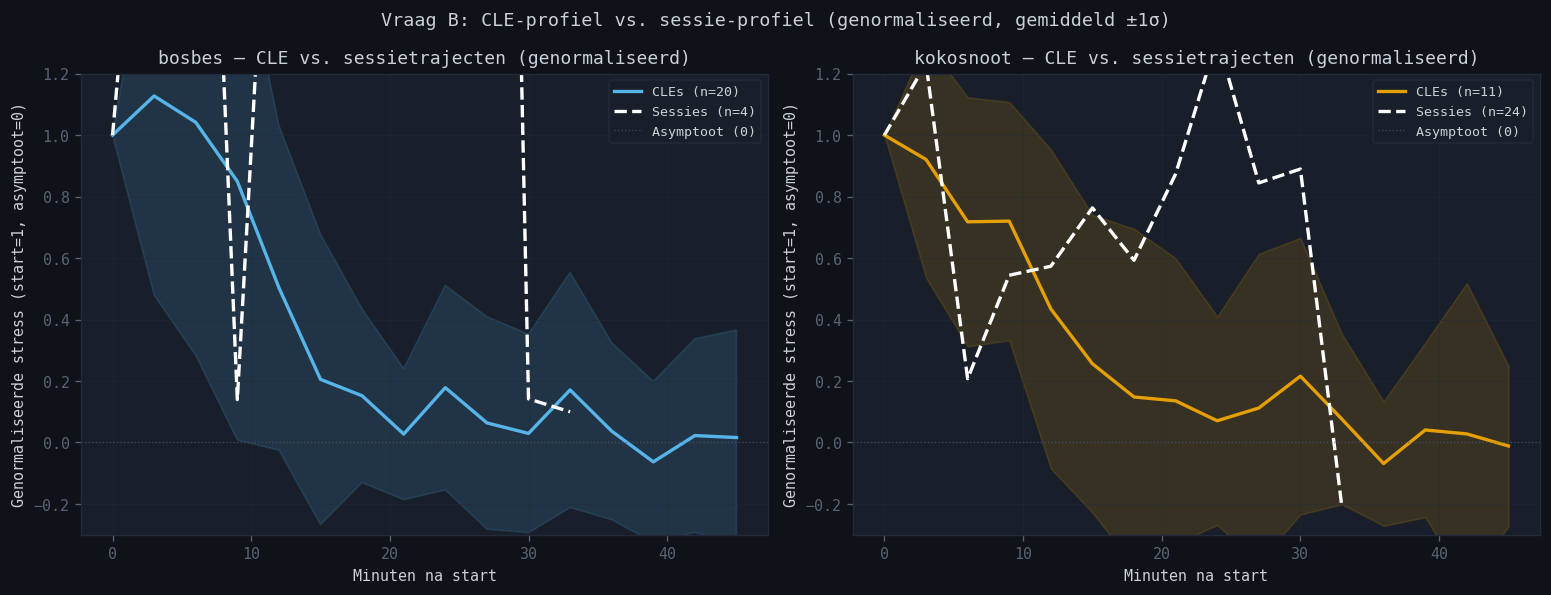


════════════════════════════════════════════════════════════
VRAAG C — Is body-battery-daling bewijs tégen muziek?
════════════════════════════════════════════════════════════

bosbes:
  Sessie BB-delta:  n=7, mediaan=-1.0, % negatief=71%
  CLE BB-delta:     n=73, mediaan=-2.0, % negatief=90%
  → Sessies zijn ook overwegend negatief: BB-daling is NIET onderscheidend.
    Dit is geen argument tégen muziek in CLEs.

kokosnoot:
  Sessie BB-delta:  n=36, mediaan=-2.0, % negatief=89%
  CLE BB-delta:     n=11, mediaan=-4.0, % negatief=100%
  → Sessies zijn ook overwegend negatief: BB-daling is NIET onderscheidend.
    Dit is geen argument tégen muziek in CLEs.


In [42]:
if not all_cles.empty:
    # ── VRAAG A: CLE-dagen vs. sessiedagen ────────────────────────────────────
    print("═" * 60)
    print("VRAAG A — Vallen CLEs op andere dagen dan sessies?")
    print("═" * 60)

    # Stricter subset: r²≥0.30 en tau_actual≥2 (geen degenerate fits)
    clean_cles = all_cles[(all_cles['r2'] >= 0.30) & (all_cles['tau_actual'] >= 2.0)].copy()
    print(f'\nSchoon subset (r²≥0.30, τ_werkelijk≥2): n={len(clean_cles)}')

    for codename in ['bosbes', 'kokosnoot']:
        sb_path = WEARABLES_DIR / codename / 'processed' / 'session_biometrics.csv'
        if not sb_path.exists():
            continue
        sb = pd.read_csv(sb_path)
        session_dates = set(pd.to_datetime(sb['date']).dt.date)
        p_cles = clean_cles[clean_cles['participant'] == codename].copy()
        if p_cles.empty:
            print(f'\n{codename}: geen schone CLEs')
            continue
        cle_dates = set(p_cles['timestamp'].dt.date)
        overlap   = cle_dates & session_dates
        only_cle  = cle_dates - session_dates
        pct_overlap = len(overlap) / len(cle_dates) * 100 if cle_dates else 0
        print(f'\n{codename}:')
        print(f'  Schone CLE-datums: {len(cle_dates)}')
        print(f'  Sessiedatums:      {len(session_dates)}')
        print(f'  Overlap (beide):   {len(overlap)} datums ({pct_overlap:.0f}% van CLE-datums)')
        print(f'  Alleen CLE:        {len(only_cle)} datums')
        if pct_overlap > 50:
            print(f'  → CLEs vallen grotendeels op sessiedagen — mogelijk studie-artefact.')
        else:
            print(f'  → CLEs vallen grotendeels op niet-sessiedagen — wijst op onafhankelijk gedrag.')

    # ── VRAAG B: Genormaliseerde trajectorievergelijking ──────────────────────
    print(f'\n{"═" * 60}')
    print("VRAAG B — Lijken CLE-profielen op sessieprofielen?")
    print("═" * 60)

    PROFILE_MINUTES = 45
    t_grid = np.arange(0, PROFILE_MINUTES + 1, 3, dtype=float)
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    for ax, codename in zip(axes, ['bosbes', 'kokosnoot']):
        p_cles_clean = clean_cles[clean_cles['participant'] == codename].head(20)
        pdata = participant_data.get(codename)
        if pdata is None or p_cles_clean.empty:
            ax.set_visible(False)
            continue

        df       = pdata['df']
        baselines = pdata['baselines']
        asym_default = next(iter(baselines.values()), {}).get('asymptote', 25.0)

        # ── Genormaliseerde CLE-trajecten ────────────────────────────────────
        cle_profiles = []
        for _, row in p_cles_clean.iterrows():
            ts        = row['timestamp']
            asymptote = float(row['asymptote'])
            wend = ts + pd.Timedelta(minutes=PROFILE_MINUTES)
            ws   = df.loc[ts:wend, 'stress'].dropna()
            if len(ws) < 5:
                continue
            start = float(ws.iloc[0])
            if start <= asymptote:
                continue
            t_obs  = np.array([(t_ - ts).total_seconds() / 60 for t_ in ws.index], dtype=float)
            y_norm = (ws.values.astype(float) - asymptote) / (start - asymptote)
            y_interp = np.interp(t_grid, t_obs, y_norm, right=float('nan'))
            cle_profiles.append(y_interp)

        # ── Genormaliseerde sessietrajecten ──────────────────────────────────
        traces_path = WEARABLES_DIR / codename / 'processed' / 'session_traces_all.csv'
        sess_profiles = []
        if traces_path.exists():
            traces = pd.read_csv(traces_path)
            during = traces[traces['phase'] == 'during'].copy()
            for sess_date in during['session_date'].unique():
                sess_rows = during[during['session_date'] == sess_date].sort_values('minutes_relative')
                # Only use rows where stress is available
                sess_rows = sess_rows[sess_rows['stress'].notna()].copy()
                if len(sess_rows) < 5:
                    continue
                stress_vals = sess_rows['stress'].values.astype(float)
                t_sess      = sess_rows['minutes_relative'].values.astype(float)
                t_sess      = t_sess - t_sess[0]  # start bij 0
                start = float(stress_vals[0])
                if start <= asym_default:
                    continue
                y_norm   = (stress_vals - asym_default) / (start - asym_default)
                t_max    = min(PROFILE_MINUTES, float(t_sess[-1]))
                t_g_sess = np.arange(0, t_max + 1, 3, dtype=float)
                if len(t_g_sess) < 3:
                    continue
                y_interp = np.interp(t_g_sess, t_sess, y_norm, right=float('nan'))
                # Pad / trim to t_grid length
                padded = np.full(len(t_grid), float('nan'))
                n = min(len(y_interp), len(t_grid))
                padded[:n] = y_interp[:n]
                sess_profiles.append(padded)

        if cle_profiles:
            cle_mat  = np.array(cle_profiles)
            cle_mean = np.nanmean(cle_mat, axis=0)
            cle_std  = np.nanstd(cle_mat, axis=0)
            ax.plot(t_grid, cle_mean, color=PARTICIPANT_COLORS[codename],
                    linewidth=2, label=f'CLEs (n={len(cle_mat)})')
            ax.fill_between(t_grid, cle_mean - cle_std, cle_mean + cle_std,
                            alpha=0.15, color=PARTICIPANT_COLORS[codename])

        if sess_profiles:
            sess_mat  = np.array(sess_profiles)
            sess_mean = np.nanmean(sess_mat, axis=0)
            ax.plot(t_grid, sess_mean, color='white', linewidth=2,
                    linestyle='--', label=f'Sessies (n={len(sess_mat)})')

        ax.axhline(0, color='#586475', linewidth=0.8, linestyle=':', alpha=0.6,
                   label='Asymptoot (0)')
        ax.set_xlabel('Minuten na start')
        ax.set_ylabel('Genormaliseerde stress (start=1, asymptoot=0)')
        ax.set_title(f'{codename} — CLE vs. sessietrajecten (genormaliseerd)')
        ax.set_ylim(-0.3, 1.2)
        ax.legend(fontsize=8)
        print(f'{codename}: CLE profielen={len(cle_profiles)}, sessieprofielen={len(sess_profiles)}')

    fig.suptitle('Vraag B: CLE-profiel vs. sessie-profiel (genormaliseerd, gemiddeld ±1σ)', fontsize=11)
    plt.tight_layout()
    plt.show()

    # ── VRAAG C: Body Battery delta vergelijking ──────────────────────────────
    print(f'\n{"═" * 60}')
    print("VRAAG C — Is body-battery-daling bewijs tégen muziek?")
    print("═" * 60)

    for codename in ['bosbes', 'kokosnoot']:
        traces_path = WEARABLES_DIR / codename / 'processed' / 'session_traces_all.csv'
        if not traces_path.exists():
            continue
        traces = pd.read_csv(traces_path)
        during = traces[traces['phase'] == 'during']
        if 'body_battery' not in during.columns:
            print(f'{codename}: geen body_battery in session_traces')
            continue
        bb_per = during.groupby('session_date')['body_battery'].agg(['first','last'])
        bb_per['delta'] = bb_per['last'] - bb_per['first']
        bb_valid = bb_per['delta'].dropna()

        p_cles_bb = clean_cles[
            (clean_cles['participant'] == codename) &
            clean_cles['body_battery_delta'].notna()
        ]['body_battery_delta']

        print(f'\n{codename}:')
        print(f'  Sessie BB-delta:  n={len(bb_valid)}, '
              f'mediaan={bb_valid.median():.1f}, '
              f'% negatief={(bb_valid < 0).mean()*100:.0f}%')
        if len(p_cles_bb) > 0:
            print(f'  CLE BB-delta:     n={len(p_cles_bb)}, '
                  f'mediaan={p_cles_bb.median():.1f}, '
                  f'% negatief={(p_cles_bb < 0).mean()*100:.0f}%')
            if (bb_valid < 0).mean() > 0.7:
                print('  → Sessies zijn ook overwegend negatief: BB-daling is NIET onderscheidend.')
                print('    Dit is geen argument tégen muziek in CLEs.')

In [43]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_predict, StratifiedKFold
from sklearn.metrics import classification_report

# Bouw trainingsset vanuit session_traces_all.csv
INFERENCE_FEATURES = ['advantage', 'pre_stress', 'stress_decline', 'hour']
if 'body_battery_delta' in all_cles.columns:
    INFERENCE_FEATURES.append('body_battery_delta')

train_rows = []
for codename, pdata in participant_data.items():
    sb_path = WEARABLES_DIR / codename / 'processed' / 'session_biometrics.csv'
    if not sb_path.exists():
        continue
    sb = pd.read_csv(sb_path)

    # Haal tau_expected op vanuit baselines
    baselines = pdata['baselines']

    rec_path = ANALYSIS_DIR / 'recovery_features.csv'
    if rec_path.exists():
        rec_all = pd.read_csv(rec_path)
        rec_p = rec_all[
            (rec_all['participant'] == codename) & (rec_all['reliable'] == True)
        ]
        for _, row in rec_p.iterrows():
            try:
                start_dt = pd.Timestamp(f"{row['session_date']} {sb.loc[sb['date']==row['session_date'], 'start_local'].values[0]}")
                hour = start_dt.hour
            except Exception:
                hour = 12
            train_rows.append({
                'participant':        codename,
                'playlist':           row.get('playlist', 'Unknown'),
                'advantage':          row.get('advantage', np.nan),
                'pre_stress':         row.get('pre_stress_mean', np.nan),
                'stress_decline':     np.nan,  # niet beschikbaar in recovery_features
                'hour':               hour,
                'body_battery_delta': np.nan,
            })

train_df = pd.DataFrame(train_rows)
train_df = train_df[train_df['playlist'].isin(['Calm', 'Neutral', 'Energy'])]

if len(train_df) < 10 or all_cles.empty:
    print('Te weinig trainingsdata of CLEs voor contextuele inferentie.')
else:
    X_train = train_df[[f for f in INFERENCE_FEATURES if f in train_df.columns]]
    y_train = train_df['playlist']

    clf_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler()),
        ('clf',     LogisticRegression(C=1, max_iter=500, random_state=42)),
    ])

    # LOO-CV op trainingsset (validatie van de classifier)
    if len(y_train.unique()) >= 2 and len(y_train) >= 6:
        skf   = StratifiedKFold(n_splits=min(5, y_train.value_counts().min()))
        y_cv  = cross_val_predict(clf_pipe, X_train, y_train, cv=skf)
        print('Classifier LOO-CV op geregistreerde sessies:\n')
        print(classification_report(y_train, y_cv, zero_division=0))

    # Fit op volledige trainingsset
    clf_pipe.fit(X_train, y_train)

    # Pas toe op CLEs
    feat_cols = [f for f in INFERENCE_FEATURES if f in all_cles.columns]
    X_cle = all_cles[feat_cols]
    proba = clf_pipe.predict_proba(X_cle)
    classes = clf_pipe.classes_

    for i, cls in enumerate(classes):
        all_cles[f'p_{cls.lower()}'] = proba[:, i].round(3)
    all_cles['inferred_playlist'] = clf_pipe.predict(X_cle)

    print('\nGeschatte playlistlabels voor CLEs:\n')
    label_counts = all_cles['inferred_playlist'].value_counts()
    display(label_counts)

    # Visualisatie: probabilistische verdeling per inferred playlist
    fig, ax = plt.subplots(figsize=(9, 4))
    for cls in classes:
        col   = f'p_{cls.lower()}'
        vals  = all_cles[col].dropna()
        ax.hist(vals, bins=20, alpha=0.6,
                color=PLAYLIST_COLORS.get(cls, '#888'),
                label=f'{cls} (n={label_counts.get(cls,0)})', density=True)
    ax.set_xlabel('Posterior kans (logistische regressie)')
    ax.set_ylabel('Dichtheid')
    ax.set_title(
        'Geschat playlisttype voor CLEs (speculatief)\n'
        'Classifier getraind op geregistreerde sessies — geen grondwaarheid beschikbaar'
    )
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

    print('\n⚠️ Houd er rekening mee:')
    print('  - De classifier heeft maar een kleine trainingsset (< 20 sessies)')
    print('  - CLEs zijn niet gevalideerde muziek-sessies')
    print('  - Playlistlabels zijn probabilistisch, niet conclusief')

Te weinig trainingsdata of CLEs voor contextuele inferentie.


## Samenvatting & Onderzoekswaarde

### Wat deze notebook doet

Op basis van continue smartwatch-stressdata detecteert dit notebook **Candidate Listening Events (CLEs)**: perioden buiten geregistreerde studiesessies waarbij stress sneller daalt dan de persoonlijke circadiane baseline voorspelt.

### Bevindingen (invullen na uitvoering)

| Deelnemer | CLEs gevonden | CLEs/week | Sessies/week | Ratio |
|---|---|---|---|---|
| bosbes | — | — | — | — |
| kokosnoot | — | — | — | — |
| peer | — | — | — | — |

### Wat dit *niet* bewijst

> Sneller-dan-baseline stressherstel heeft meerdere mogelijke oorzaken: **meditatie**, **middagdutje**, **lezen**, **ontspanning zonder muziek**, of eenvoudigweg **een goede dag**. Er is geen grondwaarheid. CLEs zijn statistische anomalieën — geen bevestigde muziekmomenten.

### Onderzoekswaarde

1. **Patronen in zelfinitiatie**: Vertoont de temporele verdeling van CLEs een structuur (bijv. ochtendclusters)? Dat suggereert vaste muziek-gewoontes.
2. **Dosageverhouding**: Zijn er per week meer CLEs dan geregistreerde sessies? Dan is de studiepopulatie actieve muziekgebruikers buiten studieprotocol.
3. **Biometrische consistentie**: Als CLEs een vergelijkbare advantage-distributie hebben als geregistreerde sessies, versterkt dat het argument dat de biometrische stressrespons op muziek real en detecteerbaar is.
4. **Speculatieve playlistinferentie**: Zelfs zonder validatie is het een interessante modelleerexercitie om te vragen: wat voor muziek zouden mensen spontaan kiezen?

### Suggesties voor vervolgonderzoek

- Run `uv run python scripts/wearables/garmin_pipeline.py peer` om peer's volledige pipeline-uitvoer te genereren
- Valideer CLEs retrospectief door deelnemers te vragen naar specifieke data
- Vergelijk CLE-timing met Spotify Recently Played (indien deelnemers bereid zijn te delen)
- Gebruik CLEs als pseudo-labels voor semi-supervised uitbreiding van de trainingsset